# Chapter 12: Natural Gradient Learning and Singular Learning

**Source span:** printed pages 279-314; PDF pages 282-317. The PDF span was used for orientation on chapter order, terminology, formulas, and concept boundaries only. This notebook uses original prose, code, diagrams, and generated artifacts; it does not copy textbook prose, exercises, page images, screenshots, or figures.

## Chapter Goal

This chapter asks how a learning algorithm changes when parameter space is treated as a Riemannian statistical manifold instead of a Euclidean vector space. The core lesson is visual: the ordinary gradient is steepest only after a metric has been chosen. With the Fisher metric, the natural gradient is the direction that moves most efficiently in distribution space. Near singular neural-model regions, the same metric also reveals why ordinary gradient learning can stall on plateaus and why a metric-aware update can pass through those regions without the same slowdown.

## Computational Translation Guide

| Book concept | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| Riemannian steepest descent | A positive-definite metric matrix and metric ellipses | The natural-gradient arrow is normal in the metric, not in the screen's Euclidean coordinates. |
| Fisher natural gradient | Quadratic loss paths under Euclidean and Fisher preconditioning | The natural path follows the statistically scaled direction and reaches low loss with fewer steps. |
| Absolute Hessian / saddle-free Newton | A two-dimensional saddle with Newton and absolute-Hessian directions | A signed Hessian can aim at a saddle; its absolute value flips the unstable direction into an escape direction. |
| Mirror descent | Entropy mirror map on the probability simplex | The primal simplex path is curved while the dual log-coordinate increments are straight updates plus a normalization constant. |
| MLP singularity | One-hidden-unit map `v tanh(w x)` and its Fisher eigenvalues | Axes where a parameter becomes unidentifiable have collapsed metric eigenvalues. |
| Plateau dynamics | Slow ordinary dynamics next to a critical set and faster natural/blow-down dynamics | Ordinary motion can spend many iterations near a critical region even when the plotted loss looks nearly flat. |
| Singular statistical inference | Product-parameter quotient toy model | Uniform prior mass in parameters is not uniform after collapsing equivalent behaviors. |


In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import display


def find_book_root(start: Path) -> Path:
    """Find the Information Geometry course root from common execution locations."""
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").exists() and (candidate / "utils").exists():
            return candidate
    for candidate in candidates:
        nested = candidate / "Information-Geometry-and-Its-Applications"
        if (nested / "AGENTS.md").exists() and (nested / "artifacts").exists() and (nested / "utils").exists():
            return nested
    raise RuntimeError("Could not locate Information-Geometry-and-Its-Applications course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_record, display_artifact, save_json, save_matplotlib, save_plotly_html

TOPIC = "chapter-12"
SOURCE_SPAN = "printed pages 279-314; PDF pages 282-317"
rng = np.random.default_rng(4112)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

artifact_paths: list[Path] = []
check_blocks: dict[str, dict[str, object]] = {}
BOOK_ROOT


WindowsPath('D:/Geometry/Information-Geometry-and-Its-Applications')

## Visual Storyboard And Library Routing

The chapter is routed to small, inspectable objects rather than one large simulation. Matplotlib is used for durable 2D metric, simplex, singularity, and diagnostic figures. Plotly is used once where rotating the lifted loss surface makes the two descent paths easier to inspect. NumPy supplies the metric, eigenvalue, probability, and trajectory checks. The storyboard JSON below is regenerated by the notebook so the artifact tree records what each visual is meant to teach and how it is checked.


In [2]:
storyboard = {
    "chapter_goal": "Make natural gradient and singular learning visible through metric ellipses, descent paths, dual mirror coordinates, Fisher eigenvalue collapse, and plateau diagnostics.",
    "source_span_read": {
        "printed_pages": "279-314",
        "pdf_pages": "282-317",
        "source_pdf": "Information-Geometry-and-Its-Applications/Information Geometry and Its Applications.pdf",
        "used_for": "orientation on section order, terminology, formulas, and concept boundaries only",
    },
    "library_routing": [
        {"concept": "Fisher metric steepest direction", "representation": "metric ellipses and arrows", "library": "Matplotlib + NumPy", "why": "local quadratic geometry is two-dimensional and needs durable labeled inspection"},
        {"concept": "Euclidean versus natural-gradient paths", "representation": "contours plus lifted interactive loss surface", "library": "Matplotlib + Plotly", "why": "static contours show path geometry; Plotly exposes loss height interactively"},
        {"concept": "absolute Hessian around a saddle", "representation": "signed versus absolute Hessian update arrows", "library": "Matplotlib + NumPy", "why": "the phenomenon is a 2D eigenvalue sign calculation"},
        {"concept": "mirror descent dual coordinates", "representation": "simplex path and log-ratio coordinate path", "library": "Matplotlib + NumPy", "why": "entropy mirror descent lives on a 2-simplex with exact probability checks"},
        {"concept": "MLP singular Fisher collapse", "representation": "heatmaps of minimum Fisher eigenvalue and condition number", "library": "Matplotlib + NumPy", "why": "one-hidden-unit Fisher matrices can be computed directly over a grid"},
        {"concept": "plateau and singular prior diagnostics", "representation": "singular loss, slowdown curves, product-prior histogram", "library": "Matplotlib + NumPy", "why": "small toy models isolate critical-region behavior without hiding it in a full network"},
    ],
    "visual_sequence": [
        {"artifact": "figures/fisher-metric-ellipses-steepest-direction.png", "inspection_target": "metric ellipses and the Fisher-steepest arrow", "validation": "metric norm and Cauchy equality for the natural direction"},
        {"artifact": "figures/euclidean-vs-natural-gradient-trajectories.png", "inspection_target": "ordinary and natural paths over the same objective", "validation": "both losses descend; natural final loss is smaller"},
        {"artifact": "html/natural-gradient-loss-geometry.html", "inspection_target": "descent paths lifted to loss height", "validation": "same path/loss arrays as the static trajectory check"},
        {"artifact": "figures/absolute-hessian-saddle-direction.png", "inspection_target": "Newton versus absolute-Hessian direction at a saddle", "validation": "Newton moves toward the saddle in the unstable coordinate while absolute Hessian moves away"},
        {"artifact": "figures/mirror-descent-dual-coordinate-path.png", "inspection_target": "simplex probability path and dual log-ratio path", "validation": "probabilities normalize and dual residual is an additive constant"},
        {"artifact": "figures/fisher-eigenvalue-collapse-heatmap.png", "inspection_target": "singular axes where Fisher eigenvalues collapse", "validation": "Fisher matrices are PSD and axis eigenvalues are near zero"},
        {"artifact": "figures/singular-ridge-plateau-diagnostics.png", "inspection_target": "flat critical set, plateau slowdown, and singular prior mass", "validation": "ordinary slowdown lasts longer; product prior mass spikes near zero"},
    ],
    "computational_checks": [
        "metric SPD and natural direction constrained optimum",
        "monotone Euclidean and natural objective traces",
        "simplex positivity and normalization",
        "mirror-dual update residual after removing additive log-normalizer",
        "Fisher PSD over the MLP toy grid",
        "singular-axis eigenvalue collapse",
        "artifact existence and nonzero file sizes",
    ],
}

storyboard_path = save_json(storyboard, TOPIC, "checks", "chapter-12-visual-storyboard.json")
artifact_paths.append(storyboard_path)
display_artifact(storyboard_path)


## 1. Natural Gradient As Metric Steepest Descent

In Euclidean coordinates, the steepest descent direction of a scalar loss is `-grad L`. On a Riemannian parameter manifold, equal-size moves are measured by `dtheta.T @ G @ dtheta`, so the fair unit ball is an ellipse. The steepest descent vector solves a constrained linear problem and is proportional to `-inv(G) @ grad L`. The figure below makes the constraint visible: the same screen arrow length is not the same statistical length.


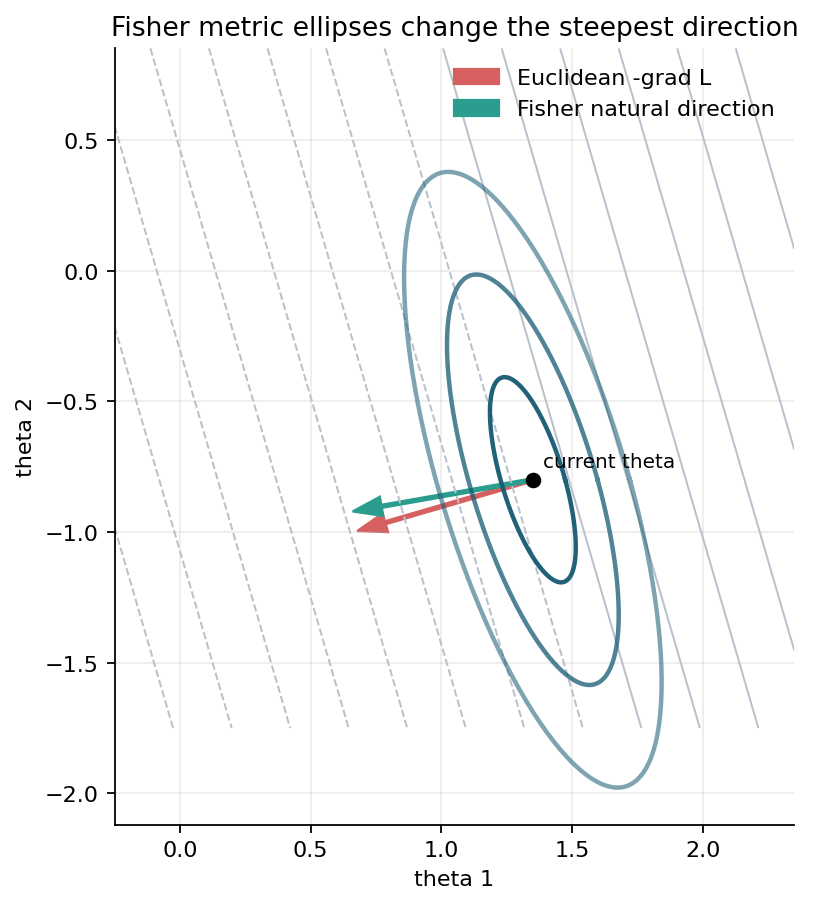

{'metric_eigenvalues': [0.733893597, 8.666106403],
 'metric_is_spd': True,
 'natural_metric_norm': 1.0000000000000002,
 'natural_cauchy_value': -0.8497132331653733,
 'cauchy_target': -0.8497132331653734,
 'euclidean_and_natural_screen_angle_degrees': 6.28814702098096}

In [3]:
def metric_ellipse(metric: np.ndarray, center: np.ndarray, radius: float, samples: int = 240) -> np.ndarray:
    angle = np.linspace(0, 2 * np.pi, samples)
    circle = np.vstack([np.cos(angle), np.sin(angle)])
    chol = np.linalg.cholesky(metric)
    offsets = np.linalg.solve(chol.T, radius * circle).T
    return offsets + center


G_local = np.array([[8.0, 2.2], [2.2, 1.4]])
theta0 = np.array([1.35, -0.80])
grad0 = np.array([2.4, 0.7])
invG_local = np.linalg.inv(G_local)
metric_norm_factor = math.sqrt(float(grad0 @ invG_local @ grad0))
natural_unit = -invG_local @ grad0 / metric_norm_factor
euclidean_unit = -grad0 / np.linalg.norm(grad0)

xv = np.linspace(-0.25, 2.35, 160)
yv = np.linspace(-1.75, 0.85, 160)
XX, YY = np.meshgrid(xv, yv)
linearized_loss = grad0[0] * (XX - theta0[0]) + grad0[1] * (YY - theta0[1])

fig, ax = plt.subplots(figsize=(7.5, 6.3))
levels = np.linspace(linearized_loss.min(), linearized_loss.max(), 16)
ax.contour(XX, YY, linearized_loss, levels=levels, colors="#b8c2cc", linewidths=0.9)
for radius, alpha in [(0.35, 0.95), (0.70, 0.75), (1.05, 0.55)]:
    ell = metric_ellipse(G_local, theta0, radius)
    ax.plot(ell[:, 0], ell[:, 1], color="#165a72", lw=2.0, alpha=alpha)
ax.arrow(theta0[0], theta0[1], 0.70 * euclidean_unit[0], 0.70 * euclidean_unit[1],
         width=0.012, head_width=0.075, length_includes_head=True, color="#d65f5f", label="Euclidean -grad L")
ax.arrow(theta0[0], theta0[1], 0.70 * natural_unit[0] / np.linalg.norm(natural_unit),
         0.70 * natural_unit[1] / np.linalg.norm(natural_unit), width=0.012,
         head_width=0.075, length_includes_head=True, color="#2a9d8f", label="Fisher natural direction")
ax.scatter([theta0[0]], [theta0[1]], color="black", zorder=5)
ax.text(theta0[0] + 0.04, theta0[1] + 0.05, "current theta", fontsize=9)
ax.set_title("Fisher metric ellipses change the steepest direction")
ax.set_xlabel("theta 1")
ax.set_ylabel("theta 2")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", frameon=False)

fisher_metric_path = save_matplotlib(fig, TOPIC, "figures", "fisher-metric-ellipses-steepest-direction.png")
plt.close(fig)
artifact_paths.append(fisher_metric_path)
display_artifact(fisher_metric_path, width=760)

metric_checks = {
    "metric_eigenvalues": np.linalg.eigvalsh(G_local).round(10).tolist(),
    "metric_is_spd": bool(np.all(np.linalg.eigvalsh(G_local) > 0)),
    "natural_metric_norm": float(natural_unit @ G_local @ natural_unit),
    "natural_cauchy_value": float(grad0 @ natural_unit),
    "cauchy_target": float(-metric_norm_factor),
    "euclidean_and_natural_screen_angle_degrees": float(np.degrees(np.arccos(np.clip(euclidean_unit @ (natural_unit / np.linalg.norm(natural_unit)), -1, 1)))),
}
assert metric_checks["metric_is_spd"]
assert abs(metric_checks["natural_metric_norm"] - 1.0) < 1e-10
assert abs(metric_checks["natural_cauchy_value"] - metric_checks["cauchy_target"]) < 1e-10
check_blocks["fisher_metric_ellipses"] = metric_checks
metric_checks


## 2. Euclidean Versus Natural-Gradient Trajectories

The next experiment uses a quadratic loss whose curvature matrix also acts as the Fisher metric, the local situation expected at a well-specified optimum. Euclidean gradient descent sees the long narrow contours directly and must choose a small step for stability. Natural gradient descent rescales by the metric, so the update is close to a coordinate-free contraction in distribution space.


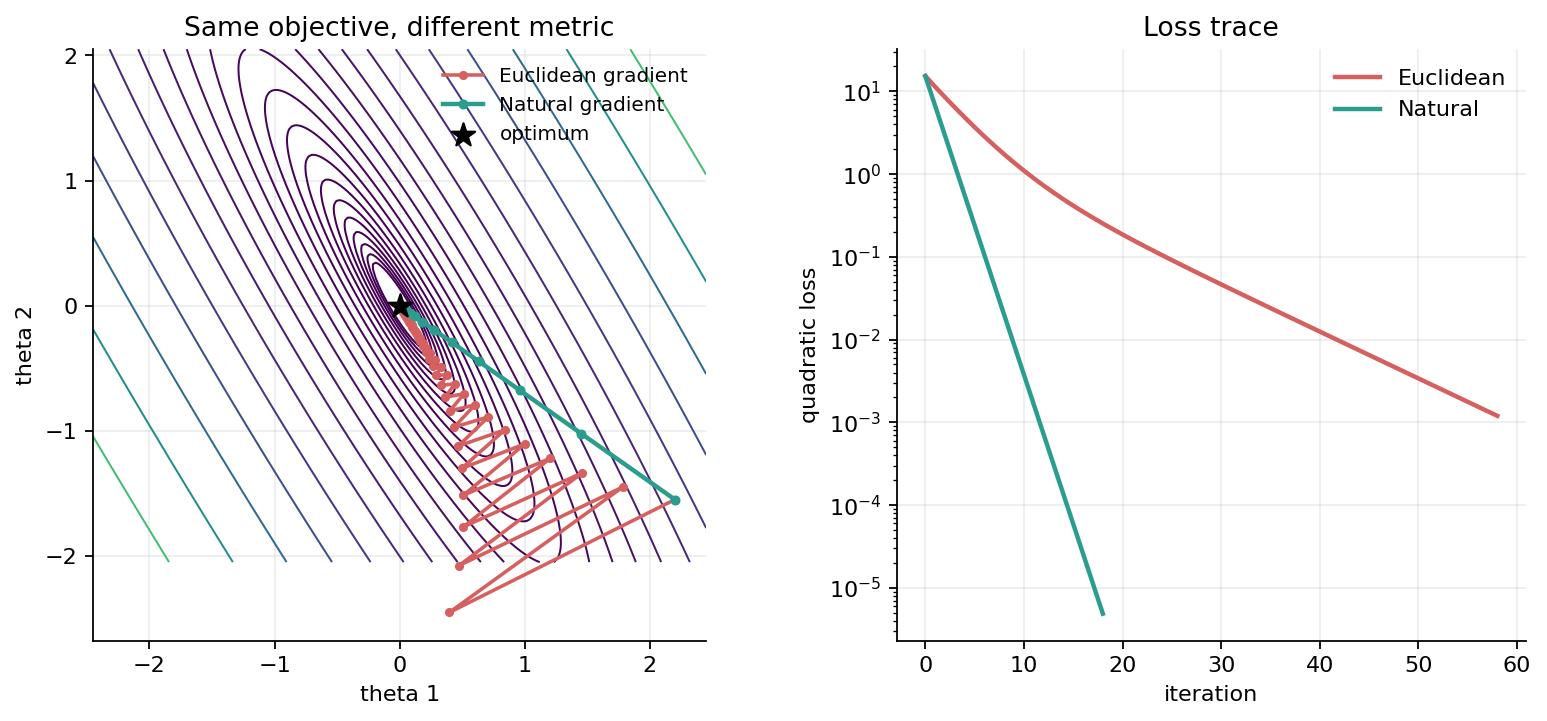

{'loss_matrix_eigenvalues': [0.75, 22.0],
 'euclidean_monotone': True,
 'natural_monotone': True,
 'euclidean_final_loss': 0.0011976086792760824,
 'natural_final_loss': 4.872202378772432e-06,
 'natural_final_below_euclidean': True,
 'condition_number': 29.333333333333304}

In [4]:
def rotation_matrix(angle: float) -> np.ndarray:
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s], [s, c]])


R = rotation_matrix(np.deg2rad(31.0))
A_loss = R @ np.diag([22.0, 0.75]) @ R.T
G_path = A_loss.copy()


def quad_loss(theta: np.ndarray) -> float:
    return 0.5 * float(theta @ A_loss @ theta)


def simulate_descent(start: np.ndarray, eta: float, steps: int, natural: bool) -> tuple[np.ndarray, np.ndarray]:
    theta = start.astype(float).copy()
    path = [theta.copy()]
    losses = [quad_loss(theta)]
    for _ in range(steps):
        grad = A_loss @ theta
        direction = np.linalg.solve(G_path, grad) if natural else grad
        theta = theta - eta * direction
        path.append(theta.copy())
        losses.append(quad_loss(theta))
    return np.asarray(path), np.asarray(losses)


start = np.array([2.20, -1.55])
euclidean_path, euclidean_losses = simulate_descent(start, eta=0.084, steps=58, natural=False)
natural_path, natural_losses = simulate_descent(start, eta=0.34, steps=18, natural=True)

gx = np.linspace(-2.45, 2.45, 220)
gy = np.linspace(-2.05, 2.05, 220)
GX, GY = np.meshgrid(gx, gy)
Z = 0.5 * (A_loss[0, 0] * GX**2 + 2 * A_loss[0, 1] * GX * GY + A_loss[1, 1] * GY**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.15, 1.0]})
axes[0].contour(GX, GY, Z, levels=np.geomspace(0.06, Z.max(), 22), cmap="viridis", linewidths=0.9)
axes[0].plot(euclidean_path[:, 0], euclidean_path[:, 1], "o-", ms=3.1, lw=1.6, color="#d65f5f", label="Euclidean gradient")
axes[0].plot(natural_path[:, 0], natural_path[:, 1], "o-", ms=3.5, lw=2.0, color="#2a9d8f", label="Natural gradient")
axes[0].scatter([0], [0], marker="*", s=120, color="black", zorder=5, label="optimum")
axes[0].set_title("Same objective, different metric")
axes[0].set_xlabel("theta 1")
axes[0].set_ylabel("theta 2")
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend(frameon=False, fontsize=9)

axes[1].semilogy(euclidean_losses, color="#d65f5f", lw=2, label="Euclidean")
axes[1].semilogy(np.arange(len(natural_losses)), natural_losses, color="#2a9d8f", lw=2, label="Natural")
axes[1].set_title("Loss trace")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("quadratic loss")
axes[1].legend(frameon=False)

trajectory_path = save_matplotlib(fig, TOPIC, "figures", "euclidean-vs-natural-gradient-trajectories.png")
plt.close(fig)
artifact_paths.append(trajectory_path)
display_artifact(trajectory_path, width=920)

trajectory_checks = {
    "loss_matrix_eigenvalues": np.linalg.eigvalsh(A_loss).round(10).tolist(),
    "euclidean_monotone": bool(np.all(np.diff(euclidean_losses) <= 1e-12)),
    "natural_monotone": bool(np.all(np.diff(natural_losses) <= 1e-12)),
    "euclidean_final_loss": float(euclidean_losses[-1]),
    "natural_final_loss": float(natural_losses[-1]),
    "natural_final_below_euclidean": bool(natural_losses[-1] < euclidean_losses[-1]),
    "condition_number": float(np.linalg.cond(A_loss)),
}
assert trajectory_checks["euclidean_monotone"] and trajectory_checks["natural_monotone"]
assert trajectory_checks["natural_final_below_euclidean"]
check_blocks["euclidean_vs_natural_paths"] = trajectory_checks
trajectory_checks


In [5]:
surface_step = 5
fig_html = go.Figure()
fig_html.add_trace(go.Surface(
    x=GX[::surface_step, ::surface_step],
    y=GY[::surface_step, ::surface_step],
    z=Z[::surface_step, ::surface_step],
    colorscale="Viridis",
    opacity=0.72,
    showscale=False,
    name="loss surface",
))
fig_html.add_trace(go.Scatter3d(
    x=euclidean_path[:, 0], y=euclidean_path[:, 1], z=euclidean_losses,
    mode="lines+markers", line=dict(color="#d65f5f", width=5), marker=dict(size=3), name="Euclidean gradient",
))
fig_html.add_trace(go.Scatter3d(
    x=natural_path[:, 0], y=natural_path[:, 1], z=natural_losses,
    mode="lines+markers", line=dict(color="#2a9d8f", width=6), marker=dict(size=4), name="Natural gradient",
))
fig_html.update_layout(
    title="Natural gradient paths lifted to the loss surface",
    scene=dict(xaxis_title="theta 1", yaxis_title="theta 2", zaxis_title="loss", camera=dict(eye=dict(x=1.4, y=-1.6, z=1.1))),
    margin=dict(l=0, r=0, t=45, b=0),
    height=560,
)
loss_html_path = save_plotly_html(fig_html, TOPIC, "html", "natural-gradient-loss-geometry.html", include_plotlyjs=True)
artifact_paths.append(loss_html_path)
display_artifact(loss_html_path, height=500)


## Where The Same Geometry Reappears

The same natural-gradient mechanism supports several chapter applications. In stochastic relaxation, a hard search over objects `x` is replaced by a search over a probability family `p(x; xi)` and the objective becomes an expectation `E_p[f(x)]`; the metric tells us how far the distribution moved, not just how far the coordinate vector moved. In policy-gradient reinforcement learning, the parameter controls a conditional action law, so the Fisher matrix of the policy scores rescales the reward gradient into a behavior-level update.

Two practical properties follow from this metric view. With a suitable `1/t` online step schedule, the natural-gradient estimator can match the asymptotic covariance predicted by the Fisher information. In saturated neural units, ordinary gradients may be tiny because derivatives of the activation nearly vanish; the Fisher scaling can restore the behavior-level direction, although the damping lab below shows why implementations usually regularize the inverse metric near singular regions.


## 3. Hessian Geometry And The Absolute-Hessian Safeguard

The chapter compares Fisher natural gradient with Newton-like Hessian geometry. The Hessian can be indefinite away from a minimum. At a saddle of `L(x, y) = (x^2 - y^2) / 2`, the ordinary Newton direction treats the negative-curvature coordinate as if moving toward zero were desirable. Replacing the Hessian eigenvalues by absolute values keeps curvature scaling while reversing that stabilizing behavior along the saddle's escape coordinate.


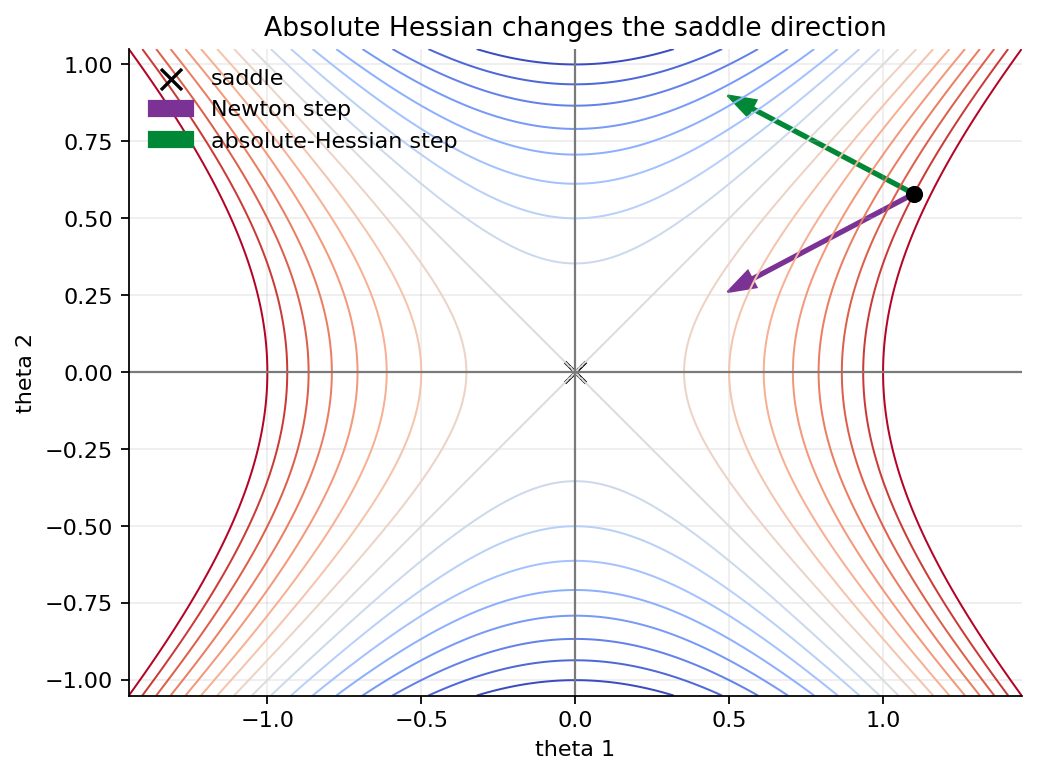

{'hessian_eigenvalues': [-1.0, 1.0],
 'absolute_hessian_eigenvalues': [1.0, 1.0],
 'newton_y_abs_after': 0.26099999999999995,
 'absolute_hessian_y_abs_after': 0.899,
 'newton_moves_toward_saddle_y': True,
 'absolute_hessian_moves_away_y': True}

In [6]:
saddle_H = np.diag([1.0, -1.0])
abs_H = np.diag(np.abs(np.diag(saddle_H)))
saddle_start = np.array([1.1, 0.58])
saddle_grad = saddle_H @ saddle_start
newton_direction = np.linalg.solve(saddle_H, saddle_grad)
abs_hessian_direction = np.linalg.solve(abs_H, saddle_grad)
eta_saddle = 0.55
newton_after = saddle_start - eta_saddle * newton_direction
abs_after = saddle_start - eta_saddle * abs_hessian_direction

sx = np.linspace(-1.45, 1.45, 200)
sy = np.linspace(-1.05, 1.05, 200)
SX, SY = np.meshgrid(sx, sy)
SLOSS = 0.5 * (SX**2 - SY**2)

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.contour(SX, SY, SLOSS, levels=np.linspace(-0.5, 0.5, 17), cmap="coolwarm", linewidths=0.9)
ax.axhline(0, color="#7a7a7a", lw=1.0)
ax.axvline(0, color="#7a7a7a", lw=1.0)
ax.scatter([0], [0], marker="x", s=90, color="black", label="saddle")
ax.scatter([saddle_start[0]], [saddle_start[1]], color="black", s=45, zorder=5)
ax.arrow(saddle_start[0], saddle_start[1], newton_after[0] - saddle_start[0], newton_after[1] - saddle_start[1],
         width=0.01, head_width=0.06, length_includes_head=True, color="#7b3294", label="Newton step")
ax.arrow(saddle_start[0], saddle_start[1], abs_after[0] - saddle_start[0], abs_after[1] - saddle_start[1],
         width=0.01, head_width=0.06, length_includes_head=True, color="#008837", label="absolute-Hessian step")
ax.set_title("Absolute Hessian changes the saddle direction")
ax.set_xlabel("theta 1")
ax.set_ylabel("theta 2")
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False, loc="upper left")

abs_hessian_path = save_matplotlib(fig, TOPIC, "figures", "absolute-hessian-saddle-direction.png")
plt.close(fig)
artifact_paths.append(abs_hessian_path)
display_artifact(abs_hessian_path, width=760)

saddle_checks = {
    "hessian_eigenvalues": np.linalg.eigvalsh(saddle_H).tolist(),
    "absolute_hessian_eigenvalues": np.linalg.eigvalsh(abs_H).tolist(),
    "newton_y_abs_after": float(abs(newton_after[1])),
    "absolute_hessian_y_abs_after": float(abs(abs_after[1])),
    "newton_moves_toward_saddle_y": bool(abs(newton_after[1]) < abs(saddle_start[1])),
    "absolute_hessian_moves_away_y": bool(abs(abs_after[1]) > abs(saddle_start[1])),
}
assert saddle_checks["newton_moves_toward_saddle_y"]
assert saddle_checks["absolute_hessian_moves_away_y"]
check_blocks["absolute_hessian_saddle"] = saddle_checks
saddle_checks


## 4. Mirror Descent As A Dual-Coordinate Natural Gradient

For negative entropy on the probability simplex, the mirror map sends probabilities to log coordinates. The update is easiest to see in two linked views. In the simplex, the path stays positive and normalized. In dual log-ratio coordinates, each step is the Euclidean gradient step plus an additive constant that only renormalizes probabilities. This is the same computational mechanism as natural gradient with metric `G(theta) = Hessian psi(theta)`.


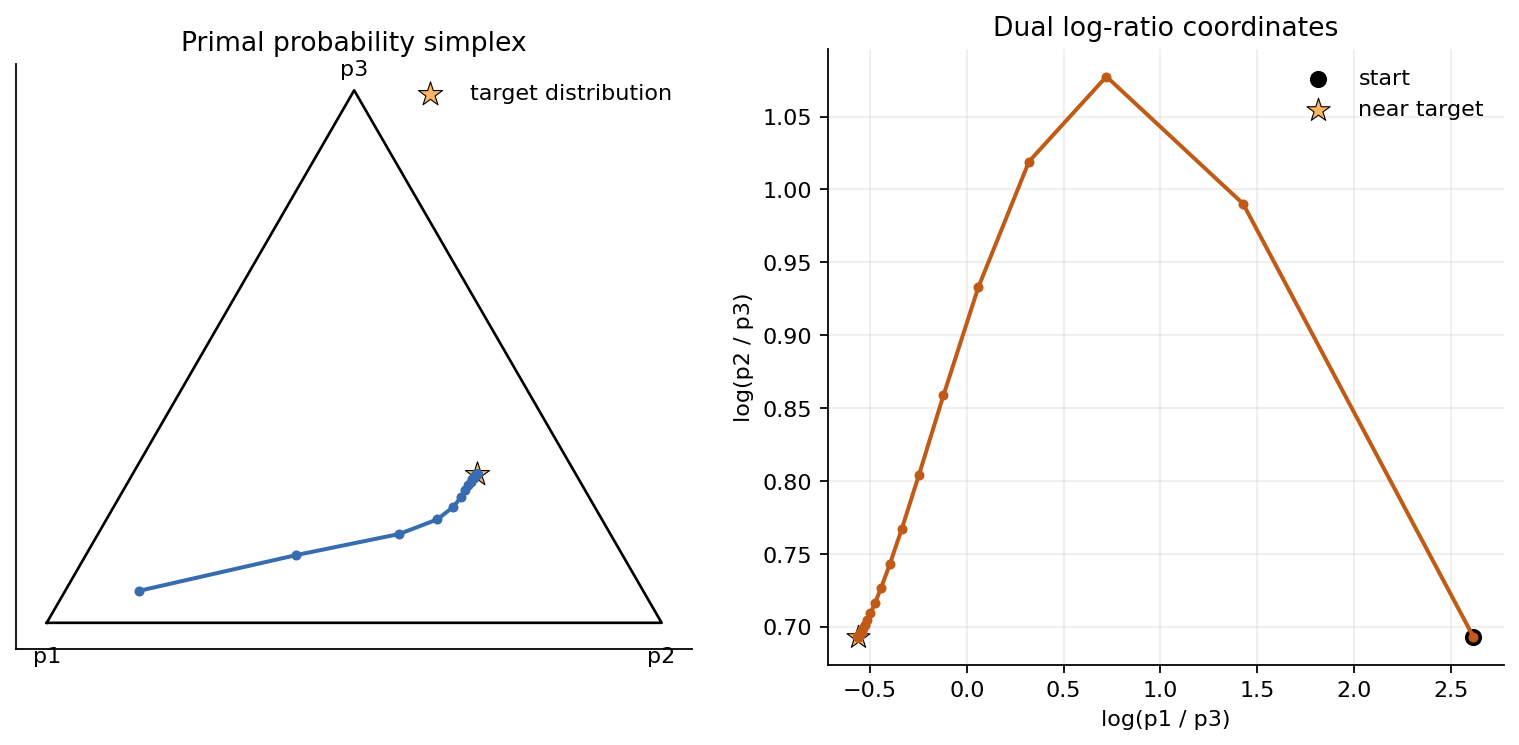

{'all_probabilities_positive': True,
 'simplex_sums_close': 2.220446049250313e-16,
 'objective_monotone': True,
 'start_objective': 0.3388,
 'final_objective': 3.361052646013007e-11,
 'max_centered_dual_update_residual': 2.42861286636753e-16}

In [7]:
def softmax(logits: np.ndarray) -> np.ndarray:
    shifted = logits - np.max(logits)
    exp_shifted = np.exp(shifted)
    return exp_shifted / exp_shifted.sum()


def simplex_xy(p: np.ndarray) -> np.ndarray:
    corners = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, math.sqrt(3) / 2]])
    return p @ corners


target_prob = np.array([0.16, 0.56, 0.28])
theta = np.array([0.82, 0.12, 0.06])
epsilon_md = 1.35
mirror_path = [theta.copy()]
mirror_objectives = [0.5 * float(np.sum((theta - target_prob) ** 2))]
dual_residuals = []
for _ in range(34):
    grad = theta - target_prob
    next_theta = softmax(np.log(theta) - epsilon_md * grad)
    dual_delta = np.log(next_theta) - np.log(theta)
    centered_observed = dual_delta - dual_delta.mean()
    centered_expected = -epsilon_md * grad - (-epsilon_md * grad).mean()
    dual_residuals.append(float(np.max(np.abs(centered_observed - centered_expected))))
    theta = next_theta
    mirror_path.append(theta.copy())
    mirror_objectives.append(0.5 * float(np.sum((theta - target_prob) ** 2)))
mirror_path = np.asarray(mirror_path)
mirror_objectives = np.asarray(mirror_objectives)
xy_path = np.asarray([simplex_xy(p) for p in mirror_path])
target_xy = simplex_xy(target_prob)
dual_path = np.column_stack([np.log(mirror_path[:, 0] / mirror_path[:, 2]), np.log(mirror_path[:, 1] / mirror_path[:, 2])])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
triangle = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, math.sqrt(3) / 2], [0.0, 0.0]])
axes[0].plot(triangle[:, 0], triangle[:, 1], color="black", lw=1.2)
axes[0].plot(xy_path[:, 0], xy_path[:, 1], "o-", color="#386cb0", ms=3.5, lw=1.8)
axes[0].scatter([target_xy[0]], [target_xy[1]], marker="*", s=130, color="#fdb462", edgecolor="black", linewidth=0.5, label="target distribution")
for label, xy in zip(["p1", "p2", "p3"], triangle[:3]):
    axes[0].text(xy[0], xy[1] - 0.055 if xy[1] == 0 else xy[1] + 0.035, label, ha="center", va="center")
axes[0].set_title("Primal probability simplex")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].legend(frameon=False, loc="upper right")

axes[1].plot(dual_path[:, 0], dual_path[:, 1], "o-", color="#bf5b17", ms=3.5, lw=1.8)
axes[1].scatter([dual_path[0, 0]], [dual_path[0, 1]], color="black", s=45, label="start")
axes[1].scatter([dual_path[-1, 0]], [dual_path[-1, 1]], marker="*", s=120, color="#fdb462", edgecolor="black", linewidth=0.5, label="near target")
axes[1].set_title("Dual log-ratio coordinates")
axes[1].set_xlabel("log(p1 / p3)")
axes[1].set_ylabel("log(p2 / p3)")
axes[1].legend(frameon=False)

mirror_path_artifact = save_matplotlib(fig, TOPIC, "figures", "mirror-descent-dual-coordinate-path.png")
plt.close(fig)
artifact_paths.append(mirror_path_artifact)
display_artifact(mirror_path_artifact, width=920)

mirror_checks = {
    "all_probabilities_positive": bool(np.all(mirror_path > 0)),
    "simplex_sums_close": float(np.max(np.abs(mirror_path.sum(axis=1) - 1.0))),
    "objective_monotone": bool(np.all(np.diff(mirror_objectives) <= 1e-12)),
    "start_objective": float(mirror_objectives[0]),
    "final_objective": float(mirror_objectives[-1]),
    "max_centered_dual_update_residual": float(max(dual_residuals)),
}
assert mirror_checks["all_probabilities_positive"]
assert mirror_checks["simplex_sums_close"] < 1e-12
assert mirror_checks["objective_monotone"]
assert mirror_checks["max_centered_dual_update_residual"] < 1e-12
check_blocks["mirror_descent_dual_coordinates"] = mirror_checks
mirror_checks


## 5. Singular Regions In A One-Hidden-Unit Model

A minimal neural singularity already appears in `f(x; w, v) = v tanh(w x)`. If `v = 0`, changing `w` does not change the output. If `w = 0`, changing `v` does not change the output because `tanh(0) = 0`. These are unidentifiable directions, so the Fisher information loses rank. The heatmaps below compute the Fisher matrix directly from output derivatives under a standard normal input distribution.


C:\Users\rahul\AppData\Local\Temp\ipykernel_3664\2588176118.py:30: RuntimeWarning: divide by zero encountered in log10
  im1 = axes[1].imshow(np.log10(condition_grid), origin="lower", extent=[param_grid.min(), param_grid.max(), param_grid.min(), param_grid.max()], cmap="viridis", aspect="auto", vmin=0, vmax=10)


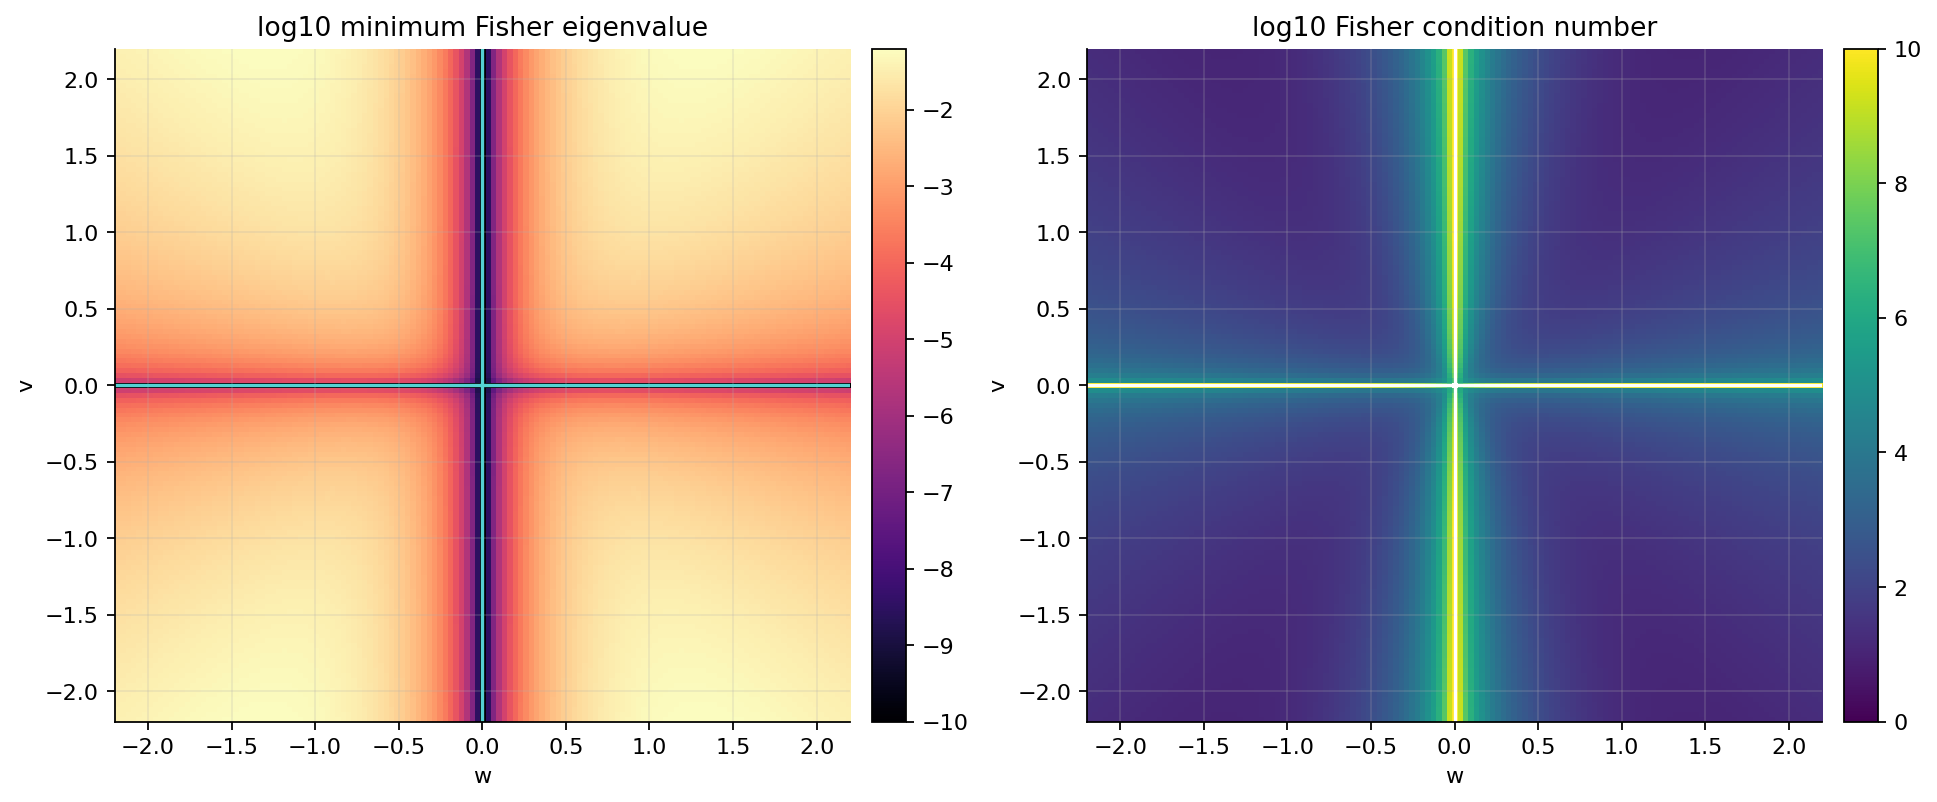

{'min_eigenvalue_global': 0.0,
 'max_eigenvalue_global': 4.839340348687816,
 'axis_min_eigenvalue_max': 0.0,
 'off_axis_min_eigenvalue_median': 0.019194934797524016,
 'axis_collapse_ratio': 0.0,
 'fisher_grid_psd': True,
 'condition_number_max_clipped': 48393403486.87816}

In [8]:
quad_x = np.linspace(-4.5, 4.5, 361)
quad_weights = np.exp(-0.5 * quad_x**2)
quad_weights = quad_weights / quad_weights.sum()
param_grid = np.linspace(-2.2, 2.2, 137)
W, V = np.meshgrid(param_grid, param_grid, indexing="xy")
U = W[..., None] * quad_x
TANH = np.tanh(U)
SECH2 = 1.0 / np.cosh(np.clip(U, -30, 30)) ** 2
J_w = V[..., None] * quad_x * SECH2
J_v = TANH
G_ww = np.sum(quad_weights * J_w * J_w, axis=-1)
G_wv = np.sum(quad_weights * J_w * J_v, axis=-1)
G_vv = np.sum(quad_weights * J_v * J_v, axis=-1)
trace_G = G_ww + G_vv
disc_G = np.sqrt(np.maximum((G_ww - G_vv) ** 2 + 4 * G_wv**2, 0.0))
fisher_lambda_min = 0.5 * (trace_G - disc_G)
fisher_lambda_max = 0.5 * (trace_G + disc_G)
fisher_lambda_min = np.maximum(fisher_lambda_min, 0.0)
condition_grid = fisher_lambda_max / np.maximum(fisher_lambda_min, 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.9), constrained_layout=True)
im0 = axes[0].imshow(np.log10(fisher_lambda_min + 1e-10), origin="lower", extent=[param_grid.min(), param_grid.max(), param_grid.min(), param_grid.max()], cmap="magma", aspect="auto")
axes[0].axhline(0, color="#54d2d2", lw=1.5)
axes[0].axvline(0, color="#54d2d2", lw=1.5)
axes[0].set_title("log10 minimum Fisher eigenvalue")
axes[0].set_xlabel("w")
axes[0].set_ylabel("v")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)

im1 = axes[1].imshow(np.log10(condition_grid), origin="lower", extent=[param_grid.min(), param_grid.max(), param_grid.min(), param_grid.max()], cmap="viridis", aspect="auto", vmin=0, vmax=10)
axes[1].axhline(0, color="white", lw=1.5)
axes[1].axvline(0, color="white", lw=1.5)
axes[1].set_title("log10 Fisher condition number")
axes[1].set_xlabel("w")
axes[1].set_ylabel("v")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)

eigen_heatmap_path = save_matplotlib(fig, TOPIC, "figures", "fisher-eigenvalue-collapse-heatmap.png")
plt.close(fig)
artifact_paths.append(eigen_heatmap_path)
display_artifact(eigen_heatmap_path, width=940)

zero_index = int(np.argmin(np.abs(param_grid)))
off_axis_mask = (np.abs(W) > 0.45) & (np.abs(V) > 0.45)
axis_values = np.concatenate([fisher_lambda_min[zero_index, :], fisher_lambda_min[:, zero_index]])
off_axis_values = fisher_lambda_min[off_axis_mask]
fisher_grid_checks = {
    "min_eigenvalue_global": float(fisher_lambda_min.min()),
    "max_eigenvalue_global": float(fisher_lambda_max.max()),
    "axis_min_eigenvalue_max": float(axis_values.max()),
    "off_axis_min_eigenvalue_median": float(np.median(off_axis_values)),
    "axis_collapse_ratio": float(axis_values.max() / np.median(off_axis_values)),
    "fisher_grid_psd": bool(fisher_lambda_min.min() >= -1e-10),
    "condition_number_max_clipped": float(condition_grid.max()),
}
assert fisher_grid_checks["fisher_grid_psd"]
assert fisher_grid_checks["axis_collapse_ratio"] < 1e-6
check_blocks["fisher_eigenvalue_heatmap"] = fisher_grid_checks
fisher_grid_checks


## 6. Plateaus, Blow-Down Coordinates, And Singular Prior Mass

The singular axes are not just a plotting curiosity. Near a critical region, ordinary gradients can become very small in the identifiable direction, creating long plateaus. In blow-down coordinates, the collapsed singular set is treated as one behavior point, and the natural-gradient dynamics can be ordinary again. The third panel connects this to singular statistical models: a smooth parameter prior can push much more mass toward a collapsed behavior than a regular model intuition would suggest.


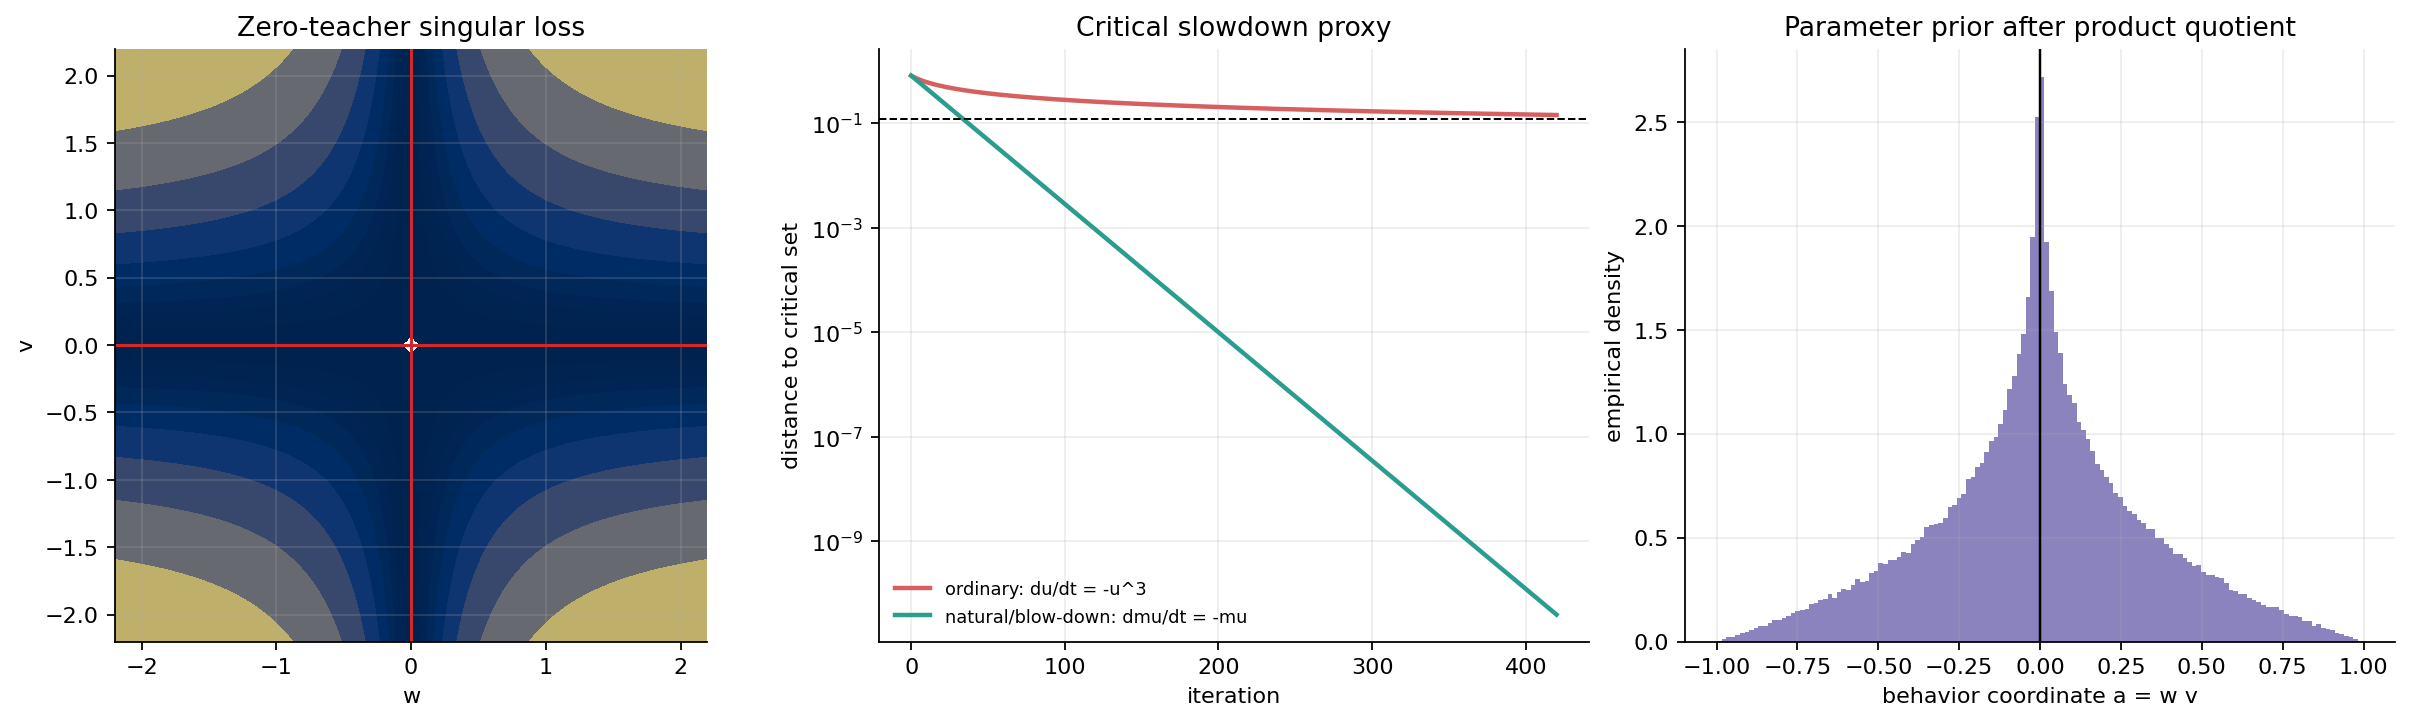

{'singular_loss_min': 0.0,
 'axis_loss_max': 0.0,
 'ordinary_iterations_to_threshold': 421,
 'natural_iterations_to_threshold': 34,
 'ordinary_slower_than_natural': True,
 'near_zero_product_prior_mass': 0.13501666666666667,
 'away_product_prior_mass_0_45_to_0_51': 0.044394444444444445,
 'singular_prior_mass_spike': True}

In [9]:
singular_loss = 0.5 * (V**2) * np.sum(quad_weights * TANH**2, axis=-1)

ordinary_u = [0.82]
natural_mu = [0.82]
for _ in range(420):
    ordinary_u.append(ordinary_u[-1] - 0.055 * ordinary_u[-1] ** 3)
    natural_mu.append(natural_mu[-1] - 0.055 * natural_mu[-1])
ordinary_u = np.asarray(ordinary_u)
natural_mu = np.asarray(natural_mu)
threshold = 0.12
ordinary_hit = int(np.argmax(ordinary_u < threshold)) if np.any(ordinary_u < threshold) else len(ordinary_u)
natural_hit = int(np.argmax(natural_mu < threshold)) if np.any(natural_mu < threshold) else len(natural_mu)

prior_w = rng.uniform(-1, 1, 180_000)
prior_v = rng.uniform(-1, 1, 180_000)
behavior_product = prior_w * prior_v
near_zero_mass = float(np.mean(np.abs(behavior_product) < 0.03))
away_mass = float(np.mean((np.abs(behavior_product) > 0.45) & (np.abs(behavior_product) < 0.51)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
levels = np.geomspace(max(singular_loss[singular_loss > 0].min(), 1e-8), singular_loss.max(), 24)
axes[0].contourf(W, V, singular_loss + 1e-10, levels=levels, cmap="cividis")
axes[0].axhline(0, color="#d62728", lw=1.4)
axes[0].axvline(0, color="#d62728", lw=1.4)
axes[0].set_title("Zero-teacher singular loss")
axes[0].set_xlabel("w")
axes[0].set_ylabel("v")
axes[0].set_aspect("equal", adjustable="box")

axes[1].semilogy(ordinary_u, color="#d65f5f", lw=2.0, label="ordinary: du/dt = -u^3")
axes[1].semilogy(natural_mu, color="#2a9d8f", lw=2.0, label="natural/blow-down: dmu/dt = -mu")
axes[1].axhline(threshold, color="black", lw=0.9, ls="--")
axes[1].set_title("Critical slowdown proxy")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("distance to critical set")
axes[1].legend(frameon=False, fontsize=8)

axes[2].hist(behavior_product, bins=140, density=True, color="#756bb1", alpha=0.84)
axes[2].axvline(0, color="black", lw=1.1)
axes[2].set_title("Parameter prior after product quotient")
axes[2].set_xlabel("behavior coordinate a = w v")
axes[2].set_ylabel("empirical density")

singular_diag_path = save_matplotlib(fig, TOPIC, "figures", "singular-ridge-plateau-diagnostics.png")
plt.close(fig)
artifact_paths.append(singular_diag_path)
display_artifact(singular_diag_path, width=1050)

singular_checks = {
    "singular_loss_min": float(singular_loss.min()),
    "axis_loss_max": float(max(singular_loss[zero_index, :].max(), singular_loss[:, zero_index].max())),
    "ordinary_iterations_to_threshold": ordinary_hit,
    "natural_iterations_to_threshold": natural_hit,
    "ordinary_slower_than_natural": bool(ordinary_hit > natural_hit),
    "near_zero_product_prior_mass": near_zero_mass,
    "away_product_prior_mass_0_45_to_0_51": away_mass,
    "singular_prior_mass_spike": bool(near_zero_mass > away_mass),
}
assert singular_checks["axis_loss_max"] < 1e-12
assert singular_checks["ordinary_slower_than_natural"]
assert singular_checks["singular_prior_mass_spike"]
check_blocks["singular_plateau_diagnostics"] = singular_checks
singular_checks


## Applied Lab: Damping A Nearly Singular Natural Gradient

A practical natural-gradient method often solves a damped linear system `(G + lambda I) direction = grad` instead of using a raw inverse. The lab below samples the one-hidden-unit model near an unidentifiable axis and records how damping changes the update norm. The point is not to find a universal damping constant. It is to see the tradeoff: too little damping can create huge steps near a collapsed eigenvalue, while too much damping erases the metric correction.


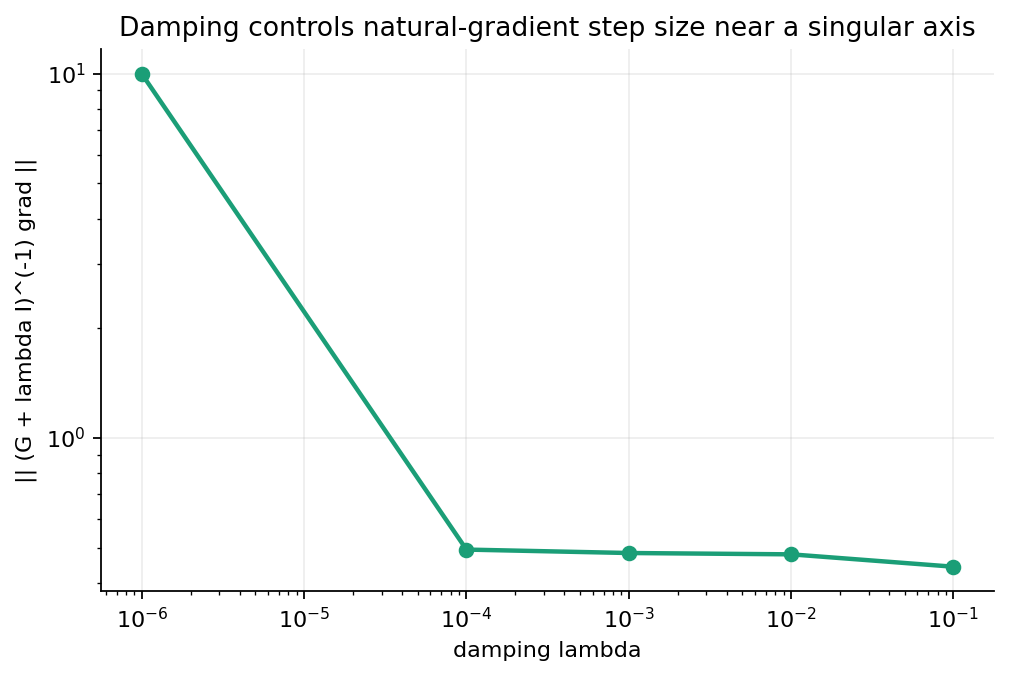

{'lab_point_w_v': [0.035, 1.05],
 'loss_at_lab_point': 0.14164197328684053,
 'fisher_eigenvalues_at_lab_point': [4.794521649706743e-09,
  1.0955339972524691],
 'gradient_norm_at_lab_point': 0.5295504984353069,
 'damping_rows': [{'damping': 1e-06,
   'direction_norm': 9.989878173282971,
   'metric_norm_with_damping': 0.256069710076546,
   'predicted_first_order_decrease': 0.25606971007654605},
  {'damping': 0.0001,
   'direction_norm': 0.49361626302136646,
   'metric_norm_with_damping': 0.25594754478736936,
   'predicted_first_order_decrease': 0.25594754478736936},
  {'damping': 0.001,
   'direction_norm': 0.4830352791644062,
   'metric_norm_with_damping': 0.2557365674200743,
   'predicted_first_order_decrease': 0.2557365674200743},
  {'damping': 0.01,
   'direction_norm': 0.47900079026922143,
   'metric_norm_with_damping': 0.2536545615986672,
   'predicted_first_order_decrease': 0.2536545615986672},
  {'damping': 0.1,
   'direction_norm': 0.44294057142927296,
   'metric_norm_with_dampi

In [10]:
def fisher_and_gradient_one_unit(w: float, v: float, teacher_w: float = 1.15, teacher_v: float = 0.85) -> tuple[np.ndarray, np.ndarray, float]:
    u = w * quad_x
    teacher = teacher_v * np.tanh(teacher_w * quad_x)
    pred = v * np.tanh(u)
    residual = pred - teacher
    sech2 = 1.0 / np.cosh(np.clip(u, -30, 30)) ** 2
    jw = v * quad_x * sech2
    jv = np.tanh(u)
    J = np.column_stack([jw, jv])
    G = (J.T * quad_weights) @ J
    grad = J.T @ (quad_weights * residual)
    loss = 0.5 * float(np.sum(quad_weights * residual**2))
    return G, grad, loss


lab_point = (0.035, 1.05)
G_lab, grad_lab, loss_lab = fisher_and_gradient_one_unit(*lab_point)
damping_values = np.array([1e-6, 1e-4, 1e-3, 1e-2, 1e-1])
lab_rows = []
for damping in damping_values:
    direction = np.linalg.solve(G_lab + damping * np.eye(2), grad_lab)
    predicted_decrease = float(grad_lab @ direction)
    lab_rows.append({
        "damping": float(damping),
        "direction_norm": float(np.linalg.norm(direction)),
        "metric_norm_with_damping": float(direction @ (G_lab + damping * np.eye(2)) @ direction),
        "predicted_first_order_decrease": predicted_decrease,
    })

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.loglog(damping_values, [row["direction_norm"] for row in lab_rows], "o-", color="#1b9e77", lw=2)
ax.set_title("Damping controls natural-gradient step size near a singular axis")
ax.set_xlabel("damping lambda")
ax.set_ylabel("|| (G + lambda I)^(-1) grad ||")
lab_path = save_matplotlib(fig, TOPIC, "figures", "metric-damping-lab.png")
plt.close(fig)
artifact_paths.append(lab_path)
display_artifact(lab_path, width=760)

lab_summary = {
    "lab_point_w_v": list(lab_point),
    "loss_at_lab_point": float(loss_lab),
    "fisher_eigenvalues_at_lab_point": np.linalg.eigvalsh(G_lab).tolist(),
    "gradient_norm_at_lab_point": float(np.linalg.norm(grad_lab)),
    "damping_rows": lab_rows,
    "step_norm_decreases_with_damping": bool(np.all(np.diff([row["direction_norm"] for row in lab_rows]) < 0)),
}
assert lab_summary["step_norm_decreases_with_damping"]
check_blocks["damped_natural_gradient_lab"] = lab_summary
lab_summary


## Sanity Checks And Artifact Manifest

The final cells collect the validation data that protects the visual claims. They check probability normalization, metric positive definiteness, descent monotonicity, Fisher eigenvalue collapse, plateau timing, the damping tradeoff, and artifact integrity. The JSON artifacts are intentionally small enough to inspect directly.


In [11]:
checks_path = save_json(check_blocks, TOPIC, "checks", "natural-gradient-singular-learning-checks.json")
artifact_paths.append(checks_path)
display(check_blocks)


{'fisher_metric_ellipses': {'metric_eigenvalues': [0.733893597, 8.666106403],
  'metric_is_spd': True,
  'natural_metric_norm': 1.0000000000000002,
  'natural_cauchy_value': -0.8497132331653733,
  'cauchy_target': -0.8497132331653734,
  'euclidean_and_natural_screen_angle_degrees': 6.28814702098096},
 'euclidean_vs_natural_paths': {'loss_matrix_eigenvalues': [0.75, 22.0],
  'euclidean_monotone': True,
  'natural_monotone': True,
  'euclidean_final_loss': 0.0011976086792760824,
  'natural_final_loss': 4.872202378772432e-06,
  'natural_final_below_euclidean': True,
  'condition_number': 29.333333333333304},
 'absolute_hessian_saddle': {'hessian_eigenvalues': [-1.0, 1.0],
  'absolute_hessian_eigenvalues': [1.0, 1.0],
  'newton_y_abs_after': 0.26099999999999995,
  'absolute_hessian_y_abs_after': 0.899,
  'newton_moves_toward_saddle_y': True,
  'absolute_hessian_moves_away_y': True},
 'mirror_descent_dual_coordinates': {'all_probabilities_positive': True,
  'simplex_sums_close': 2.220446049

In [12]:
artifact_records = [artifact_record(path) for path in artifact_paths]
for record in artifact_records:
    assert record["exists"], record
    assert record["bytes"] > 100, record

required_assertions = {
    "metric_spd": check_blocks["fisher_metric_ellipses"]["metric_is_spd"],
    "natural_path_better_final_loss": check_blocks["euclidean_vs_natural_paths"]["natural_final_below_euclidean"],
    "absolute_hessian_escapes_saddle_coordinate": check_blocks["absolute_hessian_saddle"]["absolute_hessian_moves_away_y"],
    "mirror_probabilities_normalize": check_blocks["mirror_descent_dual_coordinates"]["simplex_sums_close"] < 1e-12,
    "fisher_grid_psd": check_blocks["fisher_eigenvalue_heatmap"]["fisher_grid_psd"],
    "singular_axes_collapse": check_blocks["fisher_eigenvalue_heatmap"]["axis_collapse_ratio"] < 1e-6,
    "ordinary_plateau_slower": check_blocks["singular_plateau_diagnostics"]["ordinary_slower_than_natural"],
    "damping_reduces_step_norm": check_blocks["damped_natural_gradient_lab"]["step_norm_decreases_with_damping"],
}
assert all(bool(value) for value in required_assertions.values())

final_sanity = {
    "source_span": SOURCE_SPAN,
    "pdf_used_for": "source orientation only: section order, terminology, formulas, and concept boundaries",
    "storyboard": artifact_record(storyboard_path),
    "artifacts": artifact_records,
    "required_assertions": required_assertions,
    "topic_checks": check_blocks,
    "standalone_contract": {
        "needs_pdf_open": False,
        "uses_textbook_crops": False,
        "original_prose": True,
        "visualization_first": True,
        "paths_book_local_or_relative": True,
    },
}
final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
display(final_sanity)


{'source_span': 'printed pages 279-314; PDF pages 282-317',
 'pdf_used_for': 'source orientation only: section order, terminology, formulas, and concept boundaries',
 'storyboard': {'path': 'artifacts/chapter-12/checks/chapter-12-visual-storyboard.json',
  'exists': True,
  'bytes': 4367},
 'artifacts': [{'path': 'artifacts/chapter-12/checks/chapter-12-visual-storyboard.json',
   'exists': True,
   'bytes': 4367},
  {'path': 'artifacts/chapter-12/figures/fisher-metric-ellipses-steepest-direction.png',
   'exists': True,
   'bytes': 124068},
  {'path': 'artifacts/chapter-12/figures/euclidean-vs-natural-gradient-trajectories.png',
   'exists': True,
   'bytes': 297655},
  {'path': 'artifacts/chapter-12/html/natural-gradient-loss-geometry.html',
   'exists': True,
   'bytes': 4933583},
  {'path': 'artifacts/chapter-12/figures/absolute-hessian-saddle-direction.png',
   'exists': True,
   'bytes': 279026},
  {'path': 'artifacts/chapter-12/figures/mirror-descent-dual-coordinate-path.png',
  

## Takeaways

Natural gradient is not a cosmetic rescaling of ordinary gradient. It is the gradient after the local statistical metric defines what equal-size movement means. Mirror descent shows the same idea in dual coordinates: the update is simple in the coordinate system supplied by the convex potential, while the primal path stays constrained.

Singular learning adds a second reason to care about the metric. In the one-hidden-unit model, axes of unidentifiability collapse Fisher eigenvalues and create flat critical regions. Ordinary gradient dynamics can spend many iterations near those regions because the visible loss changes slowly. Natural-gradient and absolute-Hessian views do not remove the singularity, but they expose which directions have collapsed and provide a way to move in the behavior space instead of wandering in redundant parameters.

The statistical warning is the same geometric warning in another language: a smooth prior or a regular asymptotic argument in parameter space need not stay regular after quotienting equivalent behaviors. Singular models require diagnostics that look at rank, eigenvalues, and behavior-level coordinates, not just parameter counts.
